# Klasyfikacja emocji `sad` vs `angry` z LPC spectrogramów w bazie RAVDESS

Ten notebook realizuje kompletny pipeline klasyfikacji binarnej emocji dla bazy **RAVDESS Audio Speech Actors**. Główną cechą nie jest klasyczny spektrogram STFT, lecz **LPC spectrogram** zbudowany z obwiedni widmowej modelu all-pole wyznaczanej osobno dla każdej ramki sygnału mowy.

Analiza spełnia założenia zadania:

- wykorzystujemy wyłącznie próbki **audio-only speech** z RAVDESS,
- pozostawiamy dwie klasy: `04 = sad` oraz `05 = angry`,
- porównujemy `GradientBoostingClassifier` oraz `AdaBoostClassifier`,
- cechy są budowane dla dwóch rzędów LPC: `p = 15` i `p = 25`,
- okno analizy jest nieprostokątne: domyślnie używamy **okna Hamminga**.

Końcowy wektor cech dla pojedynczego pliku jest tworzony przez agregację LPC spectrogramu po czasie: konkatenację średniej i odchylenia standardowego dla każdego kosza częstotliwości.


In [1]:
from pathlib import Path
import random
import warnings

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import librosa
    import librosa.display
    from scipy.signal import butter, freqz, get_window, sosfiltfilt
    from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
    from sklearn.metrics import (
        accuracy_score,
        classification_report,
        f1_score,
        matthews_corrcoef,
        precision_score,
        recall_score,
    )
    from sklearn.model_selection import train_test_split
except ImportError as exc:
    raise ImportError(
        "Brakuje jednej z wymaganych bibliotek: numpy, pandas, matplotlib, librosa, scipy lub scikit-learn. \
Notebook należy uruchamiać w środowisku, w którym te pakiety są dostępne."
    ) from exc

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore', message='FigureCanvasAgg is non-interactive*')
warnings.filterwarnings('ignore', message='This figure includes Axes that are not compatible with tight_layout*')
random.seed(RANDOM_STATE)

print('Biblioteki załadowane poprawnie.')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'Librosa: {librosa.__version__}')



Biblioteki załadowane poprawnie.
NumPy: 2.4.4
Pandas: 3.0.1
Librosa: 0.11.0


## Dane i konfiguracja

Nazwy plików RAVDESS mają format podobny do `03-01-05-01-02-02-12.wav`, gdzie kolejne pola oznaczają między innymi:

- `03` - modality,
- `01` - vocal channel,
- `05` - emotion.

W tym notebooku filtrujemy tylko pliki spełniające warunki:

- `modality = 03` - audio-only,
- `vocal channel = 01` - speech,
- `emotion in {04, 05}` - odpowiednio `sad` i `angry`.

Etykiety klas przyjmują postać:

- `04 -> 0` (`sad`),
- `05 -> 1` (`angry`).


In [2]:
# =========================
# KONFIGURACJA EKSPERYMENTU
# =========================
DATASET_DIR = Path('../Lab5/Ravdess/audio_speech_actors_01-24')
SAMPLE_RATE = 8000
FRAME_MS = 25
OVERLAP = 0.40
WINDOW = 'hamming'
LPC_ORDERS = [15, 25]
N_FREQ_BINS = 128
USE_BANDPASS = False
BANDPASS_RANGE = (80.0, 3500.0)
EPS = 1e-8

EMOTION_MAP = {'04': 0, '05': 1}
EMOTION_NAME = {0: 'sad', 1: 'angry'}

def parse_ravdess_filename(path: Path):
    parts = path.stem.split('-')
    if len(parts) != 7:
        return None
    return {
        'modality': parts[0],
        'vocal_channel': parts[1],
        'emotion': parts[2],
        'emotional_intensity': parts[3],
        'statement': parts[4],
        'repetition': parts[5],
        'actor': parts[6],
    }

def collect_ravdess_speech(dataset_dir: Path):
    if not dataset_dir.exists():
        raise FileNotFoundError(f'Nie znaleziono katalogu datasetu: {dataset_dir.resolve()}')

    rows = []
    for path in sorted(dataset_dir.rglob('*.wav')):
        meta = parse_ravdess_filename(path)
        if meta is None:
            continue
        if meta['modality'] != '03':
            continue
        if meta['vocal_channel'] != '01':
            continue
        if meta['emotion'] not in EMOTION_MAP:
            continue

        label = EMOTION_MAP[meta['emotion']]
        rows.append({
            'path': path,
            'emotion_code': meta['emotion'],
            'label': label,
            'emotion_name': EMOTION_NAME[label],
            'actor': meta['actor'],
            'statement': meta['statement'],
            'repetition': meta['repetition'],
        })

    metadata = pd.DataFrame(rows)
    if metadata.empty:
        raise RuntimeError('Po filtracji nie znaleziono żadnych plików sad/angry speech.')
    return metadata

metadata = collect_ravdess_speech(DATASET_DIR)
class_counts = metadata['emotion_name'].value_counts().rename_axis('emotion').reset_index(name='count')

print(f'Katalog danych: {DATASET_DIR.resolve()}')
print(f'Liczba próbek po filtracji: {len(metadata)}')
print(class_counts.to_string(index=False))
metadata.head()


Katalog danych: /home/ezdies/SignalBioAI/Lab5/Ravdess/audio_speech_actors_01-24
Liczba próbek po filtracji: 384
emotion  count
    sad    192
  angry    192


## Ekstrakcja cech LPC

Dla każdego pliku wykonujemy następujące kroki:

1. Resampling do `SAMPLE_RATE = 8000 Hz`.
2. Podział na ramki długości `25 ms` z nakładaniem `40%`.
3. Nałożenie okna **Hamminga** na każdą ramkę.
4. Wyznaczenie współczynników LPC rzędu `p`.
5. Obliczenie widma modelu all-pole na stałej siatce częstotliwości za pomocą `scipy.signal.freqz`.
6. Zamiana do skali logarytmicznej i złożenie macierzy `frames x freq_bins`, czyli **LPC spectrogramu**.
7. Agregacja po czasie do wektora cech o stałej długości: `concat(mean, std)`.

Klasyczny STFT może służyć co najwyżej pomocniczo, ale **nie jest używany jako cecha wejściowa klasyfikatorów**.


In [3]:
frame_length = max(1, int(round(SAMPLE_RATE * FRAME_MS / 1000.0)))
hop_length = max(1, int(round(frame_length * (1.0 - OVERLAP))))
window_values = get_window(WINDOW, frame_length, fftbins=False)

def apply_optional_bandpass(signal, sr, use_bandpass=False, band=(80.0, 3500.0), order=4):
    if not use_bandpass:
        return signal

    nyquist = sr / 2.0
    low = max(band[0] / nyquist, 1e-5)
    high = min(band[1] / nyquist, 0.999)
    if low >= high:
        return signal

    sos = butter(order, [low, high], btype='bandpass', output='sos')
    return sosfiltfilt(sos, signal)

def frame_signal(signal, frame_length, hop_length):
    if len(signal) < frame_length:
        return np.empty((0, frame_length), dtype=np.float64)

    n_frames = 1 + (len(signal) - frame_length) // hop_length
    return np.stack(
        [signal[i * hop_length:i * hop_length + frame_length] for i in range(n_frames)],
        axis=0,
    )

def compute_lpc_spectrogram(
    signal,
    sr,
    order,
    frame_length,
    hop_length,
    window_values,
    n_freq_bins=128,
    use_bandpass=False,
    bandpass_range=(80.0, 3500.0),
    eps=1e-8,
):
    signal = np.asarray(signal, dtype=np.float64)
    signal = np.nan_to_num(signal)

    if signal.size < frame_length or np.max(np.abs(signal)) < eps:
        raise ValueError('Sygnał jest zbyt krótki lub pusty.')

    signal = librosa.util.normalize(signal)
    signal = apply_optional_bandpass(
        signal,
        sr,
        use_bandpass=use_bandpass,
        band=bandpass_range,
    )
    frames = frame_signal(signal, frame_length, hop_length)
    if len(frames) == 0:
        raise ValueError('Nie udało się utworzyć żadnej ramki.')

    lpc_spectra = []
    for frame in frames:
        frame = frame - np.mean(frame)
        if np.linalg.norm(frame) < eps:
            continue

        windowed = frame * window_values
        if np.linalg.norm(windowed) < eps:
            continue

        try:
            a = librosa.lpc(windowed, order=order)
            if not np.all(np.isfinite(a)):
                continue

            _, h = freqz([1.0], a, worN=n_freq_bins, fs=sr)
            power = np.abs(h) ** 2
            if not np.all(np.isfinite(power)):
                continue

            lpc_spectra.append(np.log(power + eps))
        except Exception:
            continue

    if not lpc_spectra:
        raise ValueError('Nie udało się policzyć stabilnego LPC dla żadnej ramki.')

    spectrogram = np.vstack(lpc_spectra)
    freqs = np.linspace(0.0, sr / 2.0, n_freq_bins)
    return spectrogram, freqs

def extract_feature_vector(path: Path, order: int):
    signal, sr = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    spectrogram, freqs = compute_lpc_spectrogram(
        signal=signal,
        sr=sr,
        order=order,
        frame_length=frame_length,
        hop_length=hop_length,
        window_values=window_values,
        n_freq_bins=N_FREQ_BINS,
        use_bandpass=USE_BANDPASS,
        bandpass_range=BANDPASS_RANGE,
        eps=EPS,
    )
    feature_vector = np.concatenate([spectrogram.mean(axis=0), spectrogram.std(axis=0)])
    return feature_vector, spectrogram, freqs, signal, sr

print(f'frame_length = {frame_length} próbek')
print(f'hop_length = {hop_length} próbek')
print(f'window = {WINDOW}')
print(f'feature_dim = {2 * N_FREQ_BINS}')


frame_length = 200 próbek
hop_length = 120 próbek
window = hamming
feature_dim = 256


Przykładowy plik: 03-01-04-01-01-01-01.wav (sad)


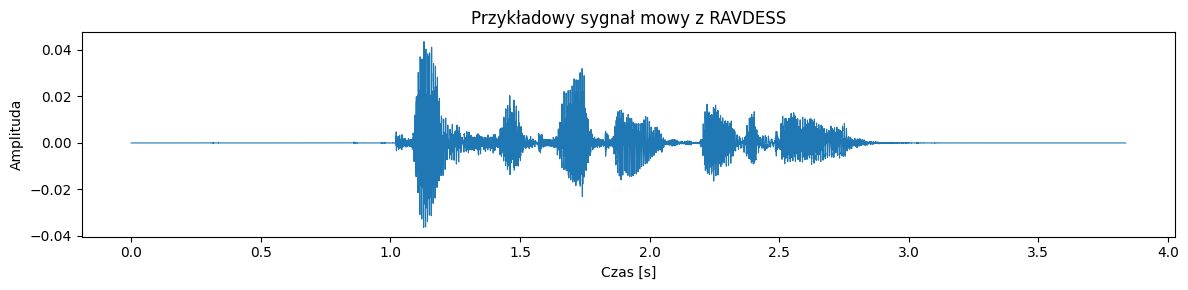

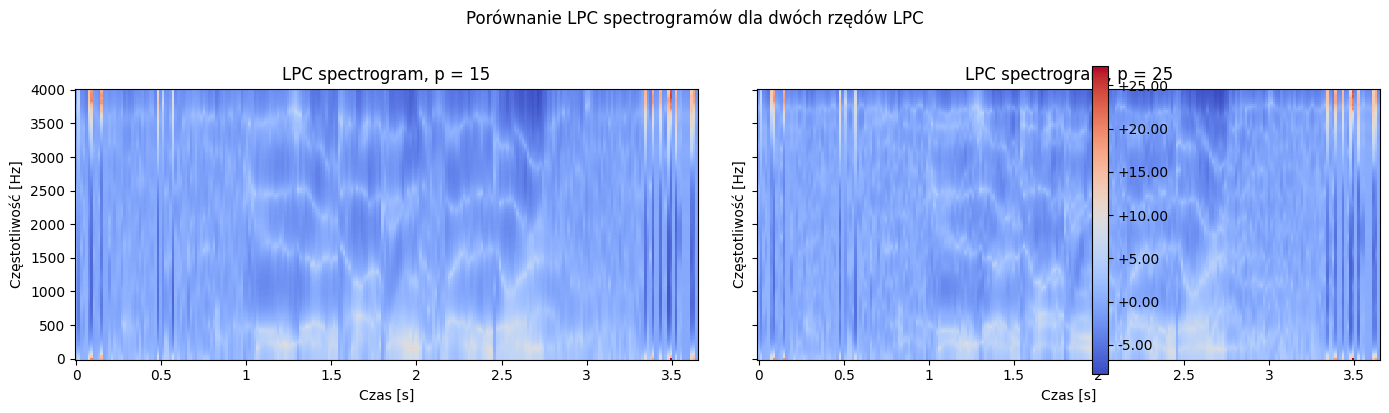

In [4]:
example_row = metadata.iloc[0]
example_path = example_row['path']
print(f'Przykładowy plik: {example_path.name} ({example_row["emotion_name"]})')

_, _, _, example_signal, example_sr = extract_feature_vector(example_path, order=LPC_ORDERS[0])
example_time = np.arange(len(example_signal)) / example_sr

plt.figure(figsize=(12, 3))
plt.plot(example_time, example_signal, linewidth=0.8)
plt.title('Przykładowy sygnał mowy z RAVDESS')
plt.xlabel('Czas [s]')
plt.ylabel('Amplituda')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, order in zip(axes, LPC_ORDERS):
    _, lpc_spec, freqs, _, sr = extract_feature_vector(example_path, order=order)
    img = librosa.display.specshow(
        lpc_spec.T,
        x_axis='time',
        y_axis='linear',
        sr=sr,
        hop_length=hop_length,
        ax=ax,
    )
    ax.set_title(f'LPC spectrogram, p = {order}')
    ax.set_ylabel('Częstotliwość [Hz]')
    ax.set_xlabel('Czas [s]')

fig.colorbar(img, ax=axes, format='%+0.2f')
fig.suptitle('Porównanie LPC spectrogramów dla dwóch rzędów LPC', y=1.02)
plt.tight_layout()
plt.show()


## Budowa zbioru cech i klasyfikacja

Dla każdego pliku wyznaczamy LPC spectrogram dla `p = 15` oraz `p = 25`, a następnie agregujemy go po czasie do stałowymiarowego wektora cech.

Podział danych jest reprodukowalny:

- `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`

Dla każdego rzędu LPC uczymy dwa klasyfikatory:

- `GradientBoostingClassifier(random_state=42)`,
- `AdaBoostClassifier(random_state=42)`.

Ewaluacja obejmuje metryki: accuracy, precision, recall, f1-score oraz MCC.


In [5]:
X_by_order = {order: [] for order in LPC_ORDERS}
y = []
valid_metadata_rows = []
skipped_files = []

for row in metadata.itertuples(index=False):
    features_for_file = {}
    file_ok = True

    for order in LPC_ORDERS:
        try:
            feature_vector, _, _, _, _ = extract_feature_vector(row.path, order)
            features_for_file[order] = feature_vector
        except Exception as exc:
            skipped_files.append((row.path.name, order, str(exc)))
            file_ok = False
            break

    if file_ok:
        for order in LPC_ORDERS:
            X_by_order[order].append(features_for_file[order])
        y.append(row.label)
        valid_metadata_rows.append(row)

y = np.asarray(y, dtype=int)
for order in LPC_ORDERS:
    X_by_order[order] = np.vstack(X_by_order[order])

print(f'Liczba poprawnie przetworzonych plików: {len(y)}')
print(f'Liczba pominiętych plików: {len(skipped_files)}')
print('Rozkład klas po ekstrakcji cech:', dict(zip(['sad', 'angry'], np.bincount(y))))
for order in LPC_ORDERS:
    print(f'p = {order}: macierz cech {X_by_order[order].shape}')


Liczba poprawnie przetworzonych plików: 384
Liczba pominiętych plików: 0
Rozkład klas po ekstrakcji cech: {'sad': np.int64(192), 'angry': np.int64(192)}
p = 15: macierz cech (384, 256)
p = 25: macierz cech (384, 256)


In [6]:
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

models = {
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'AdaBoostClassifier': AdaBoostClassifier(random_state=RANDOM_STATE),
}

results = []
reports = {}

for order in LPC_ORDERS:
    X = X_by_order[order]
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        report = classification_report(
            y_test,
            y_pred,
            target_names=['sad', 'angry'],
            zero_division=0,
        )
        reports[(model_name, order)] = report

        result_row = {
            'model': model_name,
            'lpc_order': order,
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'mcc': matthews_corrcoef(y_test, y_pred),
        }
        results.append(result_row)

        print(f'=== {model_name}, p = {order} ===')
        print(report)

results_df = pd.DataFrame(results).sort_values(
    by=['f1', 'mcc', 'accuracy'],
    ascending=False,
).reset_index(drop=True)

results_display = results_df.copy()
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'mcc']
results_display[metric_cols] = results_display[metric_cols].round(4)

print('Tabela porównawcza wyników:')
print(results_display.to_string(index=False))
results_df


=== GradientBoostingClassifier, p = 15 ===
              precision    recall  f1-score   support

         sad       0.88      0.92      0.90        39
       angry       0.92      0.87      0.89        38

    accuracy                           0.90        77
   macro avg       0.90      0.90      0.90        77
weighted avg       0.90      0.90      0.90        77

=== AdaBoostClassifier, p = 15 ===
              precision    recall  f1-score   support

         sad       0.85      0.87      0.86        39
       angry       0.86      0.84      0.85        38

    accuracy                           0.86        77
   macro avg       0.86      0.86      0.86        77
weighted avg       0.86      0.86      0.86        77

=== GradientBoostingClassifier, p = 25 ===
              precision    recall  f1-score   support

         sad       0.86      0.92      0.89        39
       angry       0.91      0.84      0.88        38

    accuracy                           0.88        77
   macr

## Dodatkowe wizualizacje skuteczności i cech `sad` / `angry`

Poniżej dodajemy dwa uzupełniające wykresy podsumowujące:

- zbiorcze porównanie metryk wszystkich eksperymentów (`accuracy`, `precision`, `recall`, `f1`, `MCC`),
- profile cech LPC dla klas `sad` i `angry`, wyznaczone jako średnie po agregowanych widmach dla obu rzędów LPC.

Dzięki temu można jednocześnie ocenić skuteczność modeli oraz zobaczyć, w których zakresach częstotliwości klasy różnią się najbardziej.

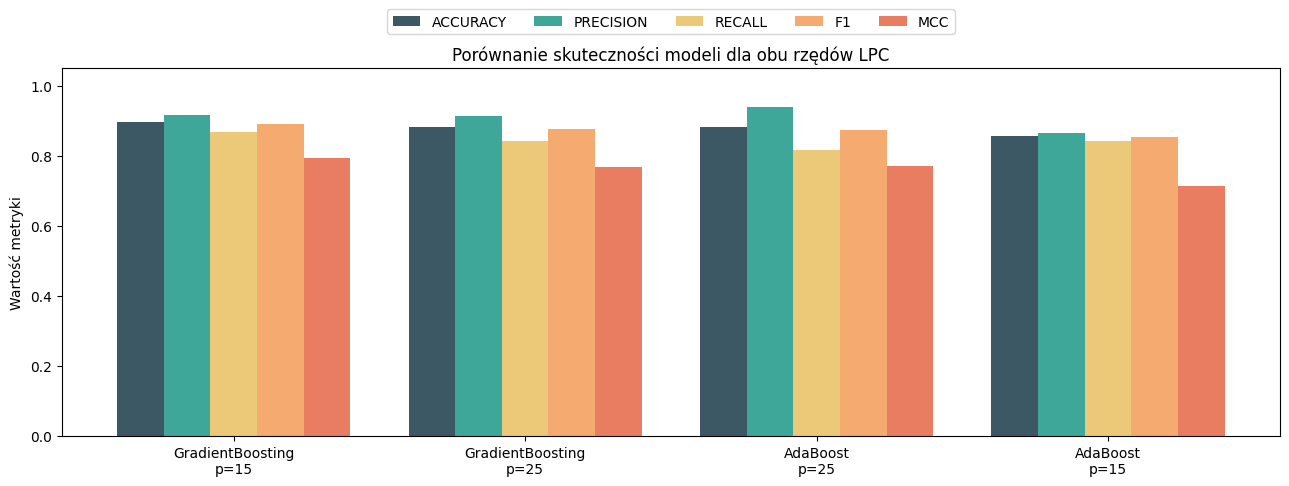

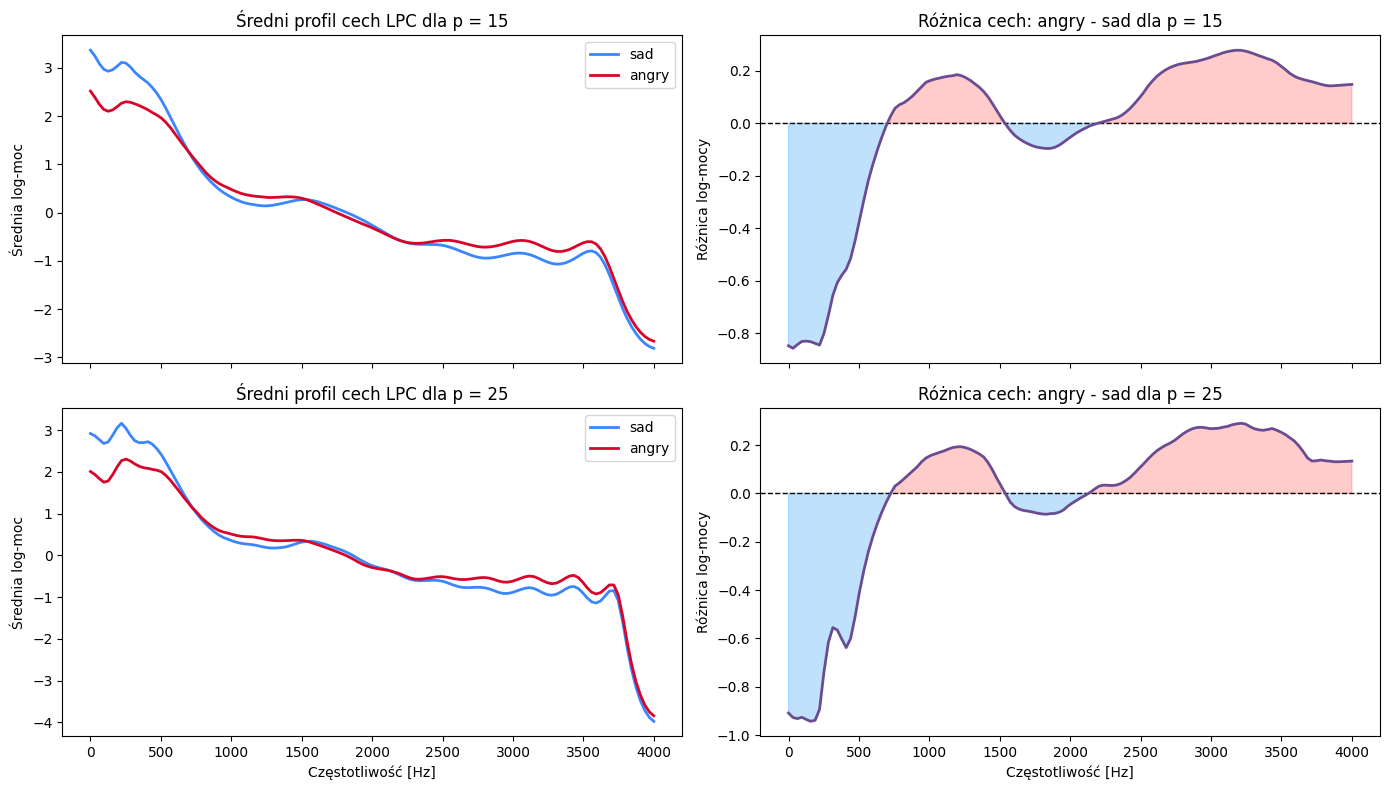

In [7]:
plot_metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'mcc']
plot_labels = [f"{row.model.replace('Classifier', '')}\np={int(row.lpc_order)}" for row in results_df.itertuples()]
plot_x = np.arange(len(results_df))
bar_width = 0.16
metric_colors = ['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']

fig, ax = plt.subplots(figsize=(13, 5))
for idx, (metric, color) in enumerate(zip(plot_metric_cols, metric_colors)):
    ax.bar(
        plot_x + (idx - 2) * bar_width,
        results_df[metric],
        width=bar_width,
        label=metric.upper(),
        color=color,
        alpha=0.9,
    )

ax.set_xticks(plot_x)
ax.set_xticklabels(plot_labels)
ax.set_ylim(0.0, 1.05)
ax.set_ylabel('Wartość metryki')
ax.set_title('Porównanie skuteczności modeli dla obu rzędów LPC')
ax.legend(ncols=5, loc='upper center', bbox_to_anchor=(0.5, 1.18))
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
freq_axis = np.linspace(0.0, SAMPLE_RATE / 2.0, N_FREQ_BINS)

for row_idx, order in enumerate(LPC_ORDERS):
    X_order = X_by_order[order]
    mean_part = X_order[:, :N_FREQ_BINS]

    sad_mean = mean_part[y == 0].mean(axis=0)
    angry_mean = mean_part[y == 1].mean(axis=0)
    diff = angry_mean - sad_mean

    ax_profile = axes[row_idx, 0]
    ax_profile.plot(freq_axis, sad_mean, label='sad', color='#3a86ff', linewidth=2)
    ax_profile.plot(freq_axis, angry_mean, label='angry', color='#d90429', linewidth=2)
    ax_profile.set_title(f'Średni profil cech LPC dla p = {order}')
    ax_profile.set_ylabel('Średnia log-moc')
    ax_profile.legend()

    ax_diff = axes[row_idx, 1]
    ax_diff.axhline(0.0, color='black', linewidth=1, linestyle='--')
    ax_diff.plot(freq_axis, diff, color='#6a4c93', linewidth=2)
    ax_diff.fill_between(freq_axis, 0.0, diff, where=diff >= 0, color='#ff6b6b', alpha=0.35)
    ax_diff.fill_between(freq_axis, 0.0, diff, where=diff < 0, color='#4dabf7', alpha=0.35)
    ax_diff.set_title(f'Różnica cech: angry - sad dla p = {order}')
    ax_diff.set_ylabel('Różnica log-mocy')

for ax in axes[-1, :]:
    ax.set_xlabel('Częstotliwość [Hz]')

plt.tight_layout()
plt.show()

In [8]:
best_row = results_df.iloc[0]
worst_row = results_df.iloc[-1]

print('Najlepsza konfiguracja według F1, następnie MCC i accuracy:')
print(
    f"- model: {best_row['model']}, rząd LPC: {int(best_row['lpc_order'])}, \
accuracy={best_row['accuracy']:.4f}, precision={best_row['precision']:.4f}, \
recall={best_row['recall']:.4f}, f1={best_row['f1']:.4f}, mcc={best_row['mcc']:.4f}"
)
print()
print('Krótki wniosek:')
print(
    f"W tym eksperymencie najlepsze wyniki uzyskał {best_row['model']} dla LPC rzędu {int(best_row['lpc_order'])}. \
Najniższy wynik miał {worst_row['model']} dla rzędu {int(worst_row['lpc_order'])}. \
Oznacza to, że dla wybranych emocji RAVDESS reprezentacja oparta na LPC spectrogramie jest wystarczająco informatywna, \
a rząd p = {int(best_row['lpc_order'])} okazał się korzystniejszy w tym podziale danych."
)


Najlepsza konfiguracja według F1, następnie MCC i accuracy:
- model: GradientBoostingClassifier, rząd LPC: 15, accuracy=0.8961, precision=0.9167, recall=0.8684, f1=0.8919, mcc=0.7931

Krótki wniosek:
W tym eksperymencie najlepsze wyniki uzyskał GradientBoostingClassifier dla LPC rzędu 15. Najniższy wynik miał AdaBoostClassifier dla rzędu 15. Oznacza to, że dla wybranych emocji RAVDESS reprezentacja oparta na LPC spectrogramie jest wystarczająco informatywna, a rząd p = 15 okazał się korzystniejszy w tym podziale danych.
